# Full-frame multi-task (U-Net + GRU): сегментация + глубина, end-to-end, GT-free

Единая модель: общий U-Net энкодер по `K=16` кадрам → декодер (**max-агрегация**
по кадрам) даёт **полнокадровую маску**; **GRU-голова** считает глубину по-дефектно,
пуля латенты по **предсказанной** маске. На инференсе GT не используется вообще:
инстансы = connected components предсказания. GT-маска нужна только как supervision.

Данные — через `TermoDataset` + `SelectFrames` (стандартный пайплайн пакета `datasets/`).
Разделы: **(1)** рычаг recall `kaggle` vs `kaggle+tpu`; **(2)** метрики; **(3)** визуализация.

In [13]:
from transforms import SelectFrames
from datasets import TermoDataset
import os
import sys
import time
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import ndimage

ROOT = "/Users/tomatocoder/Documents/thermal-control-ya-project"
# стандартные методы пакета datasets/
sys.path.insert(0, f"{ROOT}/datasets")

S, K, EP, SEED = 128, 16, 30, 67

S = 256  # переписываем

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
N_TEST = {"KaggleDataset": 5, "TPUdataset": 3}    # held-out видео на домен
# ImageNet-энкодер timm (см. последний раздел)
PRETRAINED = False
rng = np.random.default_rng(SEED)

# глубина дефекта из уровня серого маски — свой закон на домен
KAGGLE_MM = {51: 5., 102: 10., 153: 15., 204: 20., 255: 25.}


def depth_mm(domain, gray):
    if domain == "TPUdataset":
        return float(gray) / 255.0 * 6.1
    return KAGGLE_MM[min(KAGGLE_MM, key=lambda g: abs(g - gray))]


print("device:", DEVICE)

device: mps


## 1. Данные — `TermoDataset` + `SelectFrames` (стандартизовано)

In [14]:
CACHE = f"{ROOT}/experiments/lstm/.ff_cache.pkl"


def extract():
    ds = TermoDataset(f"{ROOT}/datasets/datasets_list",
                      include=["dataset_kaggle", "dataset_tpu"],
                      transform=None, standard_size=(S, S))
    items = []
    for i in range(len(ds)):
        try:
            # (K,S,S) z-score | (S,S) серый
            data, mask = ds[i]
        except Exception:
            continue
        domain = ds.items[i][2].name
        vid = os.path.splitext(os.path.basename(ds.items[i][0]))[0]
        m = mask.numpy()
        seg = (m > 0).astype(np.float32)
        lbl, n = ndimage.label(seg)
        insts = []
        for k in range(1, n + 1):
            r = (lbl == k)
            if r.sum() < 8:
                continue
            insts.append((r.astype(np.float32), depth_mm(
                domain, float(np.median(m[r])))))
        if insts:
            items.append(dict(raw=data.numpy(), seg=seg,
                         insts=insts, domain=domain, vid=vid))
    return items


if os.path.exists(CACHE):
    items = pickle.load(open(CACHE, "rb"))
else:
    items = extract()
    pickle.dump(items, open(CACHE, "wb"))


def split(items):
    tr, te = [], []
    for dom in sorted({it["domain"] for it in items}):
        vids = sorted({it["vid"] for it in items if it["domain"] == dom})
        test = set(rng.permutation(vids)[:N_TEST[dom]].tolist())
        for j, it in enumerate(items):
            if it["domain"] == dom:
                (te if it["vid"] in test else tr).append(j)
    return tr, te


TR, TE = split(items)


def depth_stats(idxs):                                 # z-score глубины на домен
    st = {}
    for dom in sorted({items[j]["domain"] for j in idxs}):
        ds_ = [d for j in idxs if items[j]["domain"]
               == dom for (_, d) in items[j]["insts"]]
        st[dom] = (float(np.mean(ds_)), float(np.std(ds_) + 1e-6))
    return st


print(f"видео={len(items)} train={len(TR)} test={len(TE)}")

видео=58 train=50 test=8


## 2. Модель — U-Net (max-агрегация) + GRU-голова глубины

In [ ]:
def cbr(i, o):
    return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.GroupNorm(8, o), nn.ReLU(),
                         nn.Conv2d(o, o, 3, padding=1), nn.GroupNorm(8, o), nn.ReLU())


class UNet(nn.Module):
    def __init__(s):
        super().__init__()
        s.d1 = cbr(1, 32)
        s.d2 = cbr(32, 64)
        s.d3 = cbr(64, 128)
        s.bott = cbr(128, 256)
        s.pool = nn.MaxPool2d(2)
        s.up = nn.Upsample(scale_factor=2)
        s.u3 = cbr(256 + 128, 128)
        s.u2 = cbr(128 + 64, 64)
        s.u1 = cbr(64 + 32, 32)
        s.outc = nn.Conv2d(32, 1, 1)

    def encode(s, x):
        e1 = s.d1(x)
        e2 = s.d2(s.pool(e1))
        e3 = s.d3(s.pool(e2))
        return s.bott(s.pool(e3)), (e1, e2, e3)

    def decode(s, b, sk):
        e1, e2, e3 = sk
        x = s.u3(torch.cat([s.up(b), e3], 1))
        x = s.u2(torch.cat([s.up(x), e2], 1))
        x = s.u1(torch.cat([s.up(x), e1], 1))
        return s.outc(x)

# /
# import timm


class FFMultiTask(nn.Module):
    """max-агрегация по K → маска; GRU по K, ROI по предсказанной маске → глубина."""
    def __init__(s, d=256):
        super().__init__()
        # enc = timm.create_model("resnet18", features_only=True, out_indices=(1,2,3,4),
                        in_chans=1, pretrained=True)  
        s.unet = UNet()
        # s.unet = enc
        s.gru = nn.GRU(d, 128, batch_first=True)
        s.head = nn.Linear(128, 1)

    def encode_seg(s, raw):
        x = torch.from_numpy(raw)[:, None].to(
            DEVICE)                 # (K,1,S,S)
        b, sk = s.unet.encode(x)
        seg = s.unet.decode(b.max(0, keepdim=True).values,
                            [e.max(0, keepdim=True).values for e in sk])[0, 0]
        return b, seg

    def depth(s, b, seg, region):
        hb, wb = b.shape[-2:]
        p = F.adaptive_avg_pool2d(torch.sigmoid(
            seg)[None, None], (hb, wb))[0, 0]
        r = F.adaptive_avg_pool2d(region[None, None], (hb, wb))[0, 0]
        # веса ← предсказание × регион
        w = r * (p + 0.1)
        pooled = (b * w).sum((-2, -1)) / (w.sum() + 1e-6)            # (K,256)
        _, hn = s.gru(pooled[None])
        return s.head(hn[-1]).squeeze()


print("параметров:", sum(p.numel() for p in FFMultiTask().parameters()))

параметров: 11318593


## 3. Обучение end-to-end + честный GT-free инференс

In [16]:
bce = nn.BCEWithLogitsLoss()
huber = nn.SmoothL1Loss()


def soft_dice(l, t, eps=1.):
    p = torch.sigmoid(l).flatten()
    t = t.flatten()
    return 1 - (2 * (p * t).sum() + eps) / (p.sum() + t.sum() + eps)


def run(domains):
    torch.manual_seed(SEED)
    tr = [j for j in TR if items[j]["domain"] in domains]
    st = depth_stats(tr)
    net = FFMultiTask().to(DEVICE)
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    t0 = time.time()
    for ep in range(EP):
        net.train()
        rng.shuffle(tr)
        for j in tr:
            it = items[j]
            mu, sd = st[it["domain"]]
            b, seg = net.encode_seg(it["raw"])
            segt = torch.from_numpy(it["seg"]).to(DEVICE)
            L = bce(seg, segt) + soft_dice(seg, segt)
            for (m, dp) in it["insts"]:
                pred = net.depth(b, seg, torch.from_numpy(m).to(DEVICE))
                L = L + huber(pred, torch.tensor((dp - mu) / sd,
                              device=DEVICE, dtype=torch.float32)) / len(it["insts"])
            opt.zero_grad()
            L.backward()
            opt.step()

    net.eval()
    out = {}
    with torch.no_grad():
        for dom in domains:
            ious = []
            dices = []
            errs = []
            ngt = ndet = nmatch = 0
            mu, sd = st[dom]
            for j in TE:
                it = items[j]
                if it["domain"] != dom:
                    continue
                b, seg = net.encode_seg(it["raw"])
                prob = torch.sigmoid(seg).cpu().numpy()
                pm = prob > 0.5
                gm = it["seg"] > 0.5
                ious.append((pm & gm).sum() / max((pm | gm).sum(), 1))
                dices.append(2 * (pm & gm).sum() / max(pm.sum() + gm.sum(), 1))
                lbl, n = ndimage.label(pm)
                preds = []                # инстансы ИЗ ПРЕДСКАЗАНИЯ
                for k in range(1, n + 1):
                    r = (lbl == k)
                    if r.sum() < 8:
                        continue
                    d = float(net.depth(b, seg, torch.from_numpy(
                        r.astype(np.float32)).to(DEVICE)).cpu()) * sd + mu
                    preds.append((r, d))
                ndet += len(preds)
                ngt += len(it["insts"])
                used = set()
                # matching GT ↔ предсказание
                for (gmask, gd) in it["insts"]:
                    gb = gmask > 0.5
                    best = -1
                    bj = -1
                    for k, (r, d) in enumerate(preds):
                        if k in used:
                            continue
                        io = (gb & r).sum() / max((gb | r).sum(), 1)
                        if io > best:
                            best = io
                            bj = k
                    if bj >= 0 and best > 0.1:
                        used.add(bj)
                        nmatch += 1
                        errs.append(abs(preds[bj][1] - gd))
            out[dom] = dict(iou=float(np.mean(ious)), dice=float(np.mean(dices)),
                            mae=float(np.mean(errs)) if errs else float("nan"),
                            recall=nmatch / max(ngt, 1), precision=nmatch / max(ndet, 1))
    return net, out, time.time() - t0


netK, rK, tK = run(["KaggleDataset"])
print(f"[kaggle] {tK:.0f}s | kaggle:", {k: round(v, 3)
      for k, v in rK["KaggleDataset"].items()})

AttributeError: 'FeatureListNet' object has no attribute 'encode'

## (1) Рычаг recall: `+tpu` домен + сводка метрик

In [11]:
import pandas as pd
netT, rT, tT = run(["KaggleDataset", "TPUdataset"])

rows = [dict(режим="kaggle", тест="kaggle", **{k: round(v, 3) for k, v in rK["KaggleDataset"].items()}),
        dict(режим="kaggle+tpu", тест="kaggle", **{k: round(v, 3) for k, v in rT["KaggleDataset"].items()})]
if "TPUdataset" in rT:
    rows.append(dict(режим="kaggle+tpu", тест="tpu", **
                {k: round(v, 3) for k, v in rT["TPUdataset"].items()}))
df = pd.DataFrame(rows)
print(df.to_string(index=False))
df

     режим   тест   iou  dice   mae  recall  precision
    kaggle kaggle 0.709 0.828 1.415   0.970      0.941
kaggle+tpu kaggle 0.673 0.802 5.857   0.939      0.969
kaggle+tpu    tpu 0.824 0.902 1.322   0.958      1.000


,режим,тест,iou,dice,mae,recall,precision
0,kaggle,kaggle,0.709,0.828,1.415,0.970,0.941
1,kaggle+tpu,kaggle,0.673,0.802,5.857,0.939,0.969
2,kaggle+tpu,tpu,0.824,0.902,1.322,0.958,1.000


## (3) Визуализация — GT-free предсказание (маска + боксы + глубина)

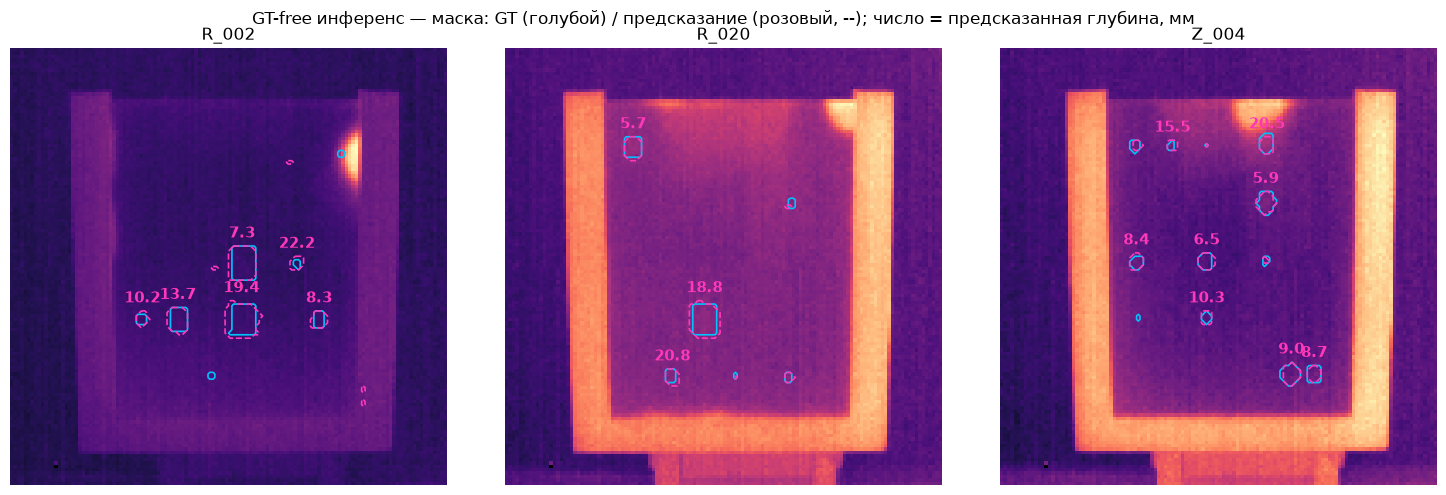

In [12]:
import matplotlib.pyplot as plt
PINK, CYAN = "#FF37B9", "#00C2FF"
kag = [j for j in TE if items[j]["domain"] == "KaggleDataset"][:3]
mu, sd = depth_stats([j for j in TR if items[j]["domain"]
                     == "KaggleDataset"])["KaggleDataset"]

netK.eval()
fig, axs = plt.subplots(1, len(kag), figsize=(5 * len(kag), 5))
axs = np.atleast_1d(axs)
with torch.no_grad():
    for ax, j in zip(axs, kag):
        it = items[j]
        b, seg = netK.encode_seg(it["raw"])
        pm = torch.sigmoid(seg).cpu().numpy() > 0.5
        ax.imshow(it["raw"][0], cmap="magma")
        ax.axis("off")
        ax.set_title(it["vid"])
        ax.contour(it["seg"] > 0.5, colors=CYAN, linewidths=1.2)
        ax.contour(pm, colors=PINK, linewidths=1.2, linestyles="--")
        lbl, n = ndimage.label(pm)
        for k in range(1, n + 1):
            r = (lbl == k)
            if r.sum() < 8:
                continue
            d = float(netK.depth(b, seg, torch.from_numpy(
                r.astype(np.float32)).to(DEVICE)).cpu()) * sd + mu
            ys, xs = np.where(r)
            ax.text(xs.mean(), ys.min(
            ) - 3, f"{d:.1f}", color=PINK, fontsize=11, ha="center", fontweight="bold")
fig.suptitle(
    "GT-free инференс — маска: GT (голубой) / предсказание (розовый, --); число = предсказанная глубина, мм")
plt.tight_layout()
plt.savefig(f"{ROOT}/experiments/lstm/ff_e2e_viz.png", dpi=130)
plt.show()

## Рычаг: ImageNet-претрейн энкодера (опционально)

`PRETRAINED=True` — заменить с-нуля-энкодер на `timm`-бэкбон (ImageNet). Для сырых
кадров вход 1-канальный, поэтому `in_chans=1` (timm усредняет RGB-веса). Требует
скачивания весов, поэтому по умолчанию выключено; при доступной сети — раскомментировать.

```python
# import timm
# enc = timm.create_model("resnet18", features_only=True, out_indices=(1,2,3,4),
#                         in_chans=1, pretrained=True)   # → заменить UNet.encode на его фичи
```
Из seg-журнала это самый сильный рычаг стабильности (σ по фолдам ↓ в ~5×).